In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
df = pd.read_csv("data/EDA.csv")

df.head()


In [ ]:
#Description:
#AHT represents the average handling time (seconds per answered case) for each employee during a working day.
#AHT = Total On Queue Time / Total Answered Case

In [ ]:
#1. Overall Performance Overview
#Number of handled tickets and AHT on average:
df[["Answered", "AHT"]].describe()



In [ ]:
df[["Answered", "AHT"]].median()

In [ ]:
#Use histogram to explore the variance of AHT and Answered number

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["AHT"].plot.hist(
    bins=40,
    ax=axes[0],
    color="cyan",
    edgecolor="white",
    alpha=0.8
)
axes[0].set_title("Overall Distribution of AHT")

df["Answered"].plot.hist(
    bins=20,
    ax=axes[1],
    color="navy",
    edgecolor="white",
    alpha=0.8
)
axes[1].set_title("Overall Distribution of Answered")

plt.tight_layout()


In [ ]:
stats.probplot(df["AHT"], dist="norm", plot=plt)

plt.show()

In [ ]:
stats.probplot(df["Answered"], dist="norm", plot=plt)

plt.show()

In [ ]:
q1_aht, median_aht, q3_aht = np.percentile(df.AHT, [25, 50, 75])
iqr_aht = q3_aht - q1_aht

q1_ans, median_ans, q3_ans = np.percentile(df.Answered, [25, 50, 75])
iqr_ans = q3_ans- q1_ans

aht = [q1_aht, q3_aht, median_aht, iqr_aht]
ans = [q1_ans, q3_ans, median_ans, iqr_ans]

attribute = ["q1", "q3", "median", "IQR"]

pd.DataFrame({
    "attribute": attribute,
    "AHT_box": aht,
    "Answered_box": ans  
})


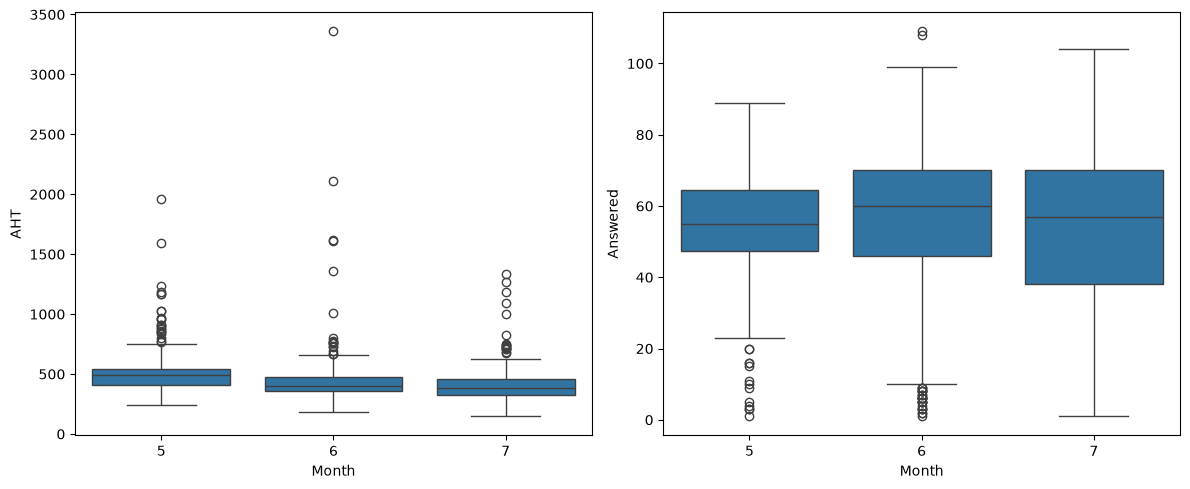

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(
    data=df,
    x="Month",
    y="AHT",
    ax=axes[0]
)

sns.boxplot(
    data=df,
    x="Month",
    y="Answered",
    ax=axes[1]
)

plt.tight_layout()

## Descriptive Statistics

The **median AHT is 411 seconds** per answered case, while the **median number of answered cases is 58**. The noticeable gap between the minimum and maximum values suggests substantial variation in employee performance across workdays.

## Histogram

The histogram indicates that AHT is **positively skewed**. Most observations fall between approximately 360 and 510 seconds, while a relatively small number of observations extend into the upper tail. These high values may correspond to workdays involving more complex customer cases or operational disruptions.

## QQ Plot

The QQ plot further confirms that AHT **deviates from a normal distribution**. While observations near the center align reasonably well with the theoretical normal line, the upper tail bends upward, indicating a heavy right tail and several unusually high AHT observations.

---

> **Overall Summary:** AHT displays a positively skewed distribution with several high-value observations, while Answered appears more concentrated around its central tendency. Since this section only examines the overall characteristics of the dataset, the next section investigates whether these patterns differ across work shifts.

In [ ]:
#2. Shift Analysis

In [ ]:
df_shift_insight = df.groupby("Shift").agg(
    avg_AHT=("AHT", "mean"),
    avg_Answered=("Answered", "mean")
).reset_index()

overall_mean_aht = df["AHT"].mean()
overall_mean_answered = df["Answered"].mean()


df_shift_insight["diff_AHT_vs_overall"] = df_shift_insight["avg_AHT"] - overall_mean_aht
df_shift_insight["diff_Answered_vs_overall"] = df_shift_insight["avg_Answered"] - overall_mean_answered

df_shift_insight



**Day Shift** demonstrates above-average performance on both operational metrics, with lower-than-average **AHT** and higher-than-average Answered cases.

**Noon Shift** handles a relatively high workload, although the average handling time is also slightly longer than the overall average.

**Night Shift** records the lowest average number of answered cases while maintaining a lower-than-average **AHT**. 

>This pattern may indicate a lighter workload or differences in operational conditions, although additional analyses are required to determine the underlying causes.

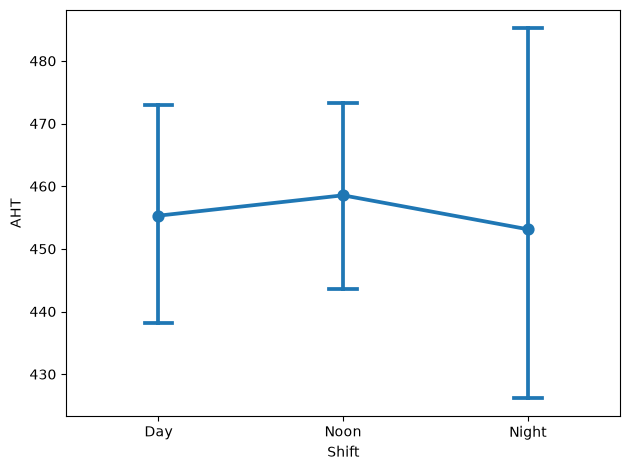

In [41]:

df["pos"] = np.where(df["Shift"] == "Day", 1, np.where(df["Shift"] == "Noon", 2, 3))

df = df.sort_values(["WD EID", "Emp Name", "Year", "Month", "pos"])

sns.pointplot(
    data=df,
    x="Shift",
    y="AHT",
    estimator=np.mean,
    errorbar=("ci", 95),
    capsize=0.15
)

plt.tight_layout()

In [ ]:
AHT_median_mean = df.groupby(["Shift"]).agg(
    mean_AHT = ("AHT", "mean"),
    median_AHT = ("AHT","median")
)

AHT_median_mean["diff(second)"] = round(abs(AHT_median_mean.mean_AHT - AHT_median_mean.median_AHT), 2)

AHT_median_mean

In [ ]:
#Histogram by shift 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


Histo_day = df.loc[df.Shift == "Day", ["AHT"]]
Histo_noon = df.loc[df.Shift == "Noon", ["AHT"]]
Histo_night = df.loc[df.Shift == "Night", ["AHT"]]


Histo_day["AHT"].plot.hist(
    bins=30,
    ax=axes[0],
    color="#57b884",
    edgecolor="white",
    alpha=0.8
)
axes[0].set_title("Distribution of AHT by Day Shift")

Histo_noon["AHT"].plot.hist(
    bins=30,
    ax=axes[1],
    color="#707c05",
    edgecolor="white",
    alpha=0.8
)
axes[1].set_title("Distribution of AHT by Noon Shift")

Histo_night["AHT"].plot.hist(
    bins=30,
    ax=axes[2],
    color="#ee941f",
    edgecolor="white",
    alpha=0.8
)
axes[2].set_title("Distribution of AHT by Night Shift")

plt.tight_layout()

In [ ]:
#QQ plot by shift 

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

stats.probplot(Histo_day["AHT"], dist="norm", plot=ax[0])
ax[0].set_title("Day Shift Distributrion")

stats.probplot(Histo_noon["AHT"], dist="norm", plot=ax[1])
ax[1].set_title("Noon Shift Distributrion")

stats.probplot(Histo_night["AHT"], dist="norm", plot=ax[2])
ax[2].set_title("Night Shift Distributrion")

plt.tight_layout()
plt.show()


In [ ]:
#Violin plot by shift (KDE observing)
ax = sns.violinplot(x="Shift", y="AHT", data=df, hue="Shift")
ax.set_title("AHT distribution by Shift")


plt.tight_layout()

In [ ]:
#Box plot
sns.boxplot(
    data=df,
    x="Shift",
    y="AHT",
)



# Distribution by Shift – Summary

The comparative analysis across work shifts reveals several noteworthy patterns in employee performance. Although the average AHT differs only slightly among the Day, Noon, and Night shifts, the underlying distributions vary considerably.

The Day Shift exhibits the most concentrated distribution, with relatively fewer extreme observations and a narrower spread around the median. This indicates lower variability in daily AHT compared with the other shifts.

In contrast, both the Noon and Night Shifts display noticeably longer right tails, accompanied by a greater number of high-end observations. The Night Shift, in particular, contains the most extreme AHT values and the widest overall distribution. These findings suggest greater variability in employee performance during these shifts rather than consistently higher average handling times.

Importantly, the observed differences relate primarily to the shape and spread of the distributions, rather than substantial differences in the group means. Therefore, comparing average AHT alone would not fully capture the operational characteristics of each work shift.

>Since all three groups exhibit visible departures from normality—especially in their upper tails—the visual evidence suggests that the normality assumption may not be satisfied. Consequently, formal assumption testing, including the Shapiro–Wilk normality test and Levene's test for homogeneity of variances, is required before selecting the appropriate statistical hypothesis test to evaluate whether work shifts significantly influence AHT.

In [88]:
#3. Temporal Performance Analysis

In [89]:
df_AHT_Ans_trend = df.groupby(["Month", "Dayofweek"]).agg(
    avg_AHT_weekday = ("AHT", "mean"),
    avg_Answered_weekday = ("Answered", "mean")
).reset_index()
Month_AHT_Ans = df.groupby("Month").agg(
    avg_AHT_month = ("AHT", "mean"),
    avg_Answered_month = ("Answered", "mean")
)

reports = pd.merge(df_AHT_Ans_trend, Month_AHT_Ans, how="inner", left_on="Month", right_on="Month")

reports = reports.assign(
    AHT_diff = (((reports.avg_AHT_weekday - reports.avg_AHT_month)/reports.avg_AHT_month)*100).map("{:.2f}%".format),
    Answered_diff = (((reports.avg_Answered_weekday - reports.avg_Answered_month)/reports.avg_Answered_month)*100).map("{:.2f}%".format),
)

reports.sort_values(["Month", "AHT_diff", "Answered_diff"], ascending=[True, False, True])


# 0 - Monday, 6 - Sunday

,Month,Dayofweek,avg_AHT_weekday,avg_Answered_weekday,avg_AHT_month,avg_Answered_month,AHT_diff,Answered_diff
2,5,2,566.413793,49.379310,524.247191,53.554307,8.04%,-7.80%
5,5,5,548.100000,53.475000,524.247191,53.554307,4.55%,-0.15%
0,5,0,536.783784,53.783784,524.247191,53.554307,2.39%,0.43%
6,5,6,526.237288,55.847458,524.247191,53.554307,0.38%,4.28%
4,5,4,505.861111,55.694444,524.247191,53.554307,-3.51%,4.00%
1,5,1,471.028571,51.542857,524.247191,53.554307,-10.15%,-3.76%
3,5,3,516.709677,52.709677,524.247191,53.554307,-1.44%,-1.58%
7,6,0,472.180723,54.337349,440.768116,55.657005,7.13%,-2.37%
9,6,2,467.206897,49.948276,440.768116,55.657005,6.00%,-10.26%
12,6,5,460.044444,50.400000,440.768116,55.657005,4.37%,-9.45%


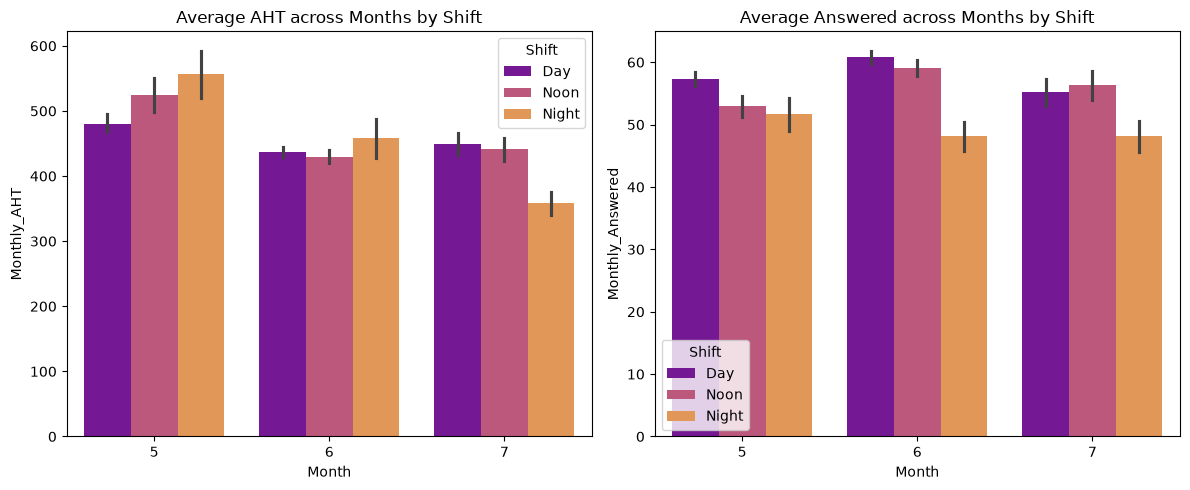

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=df.sort_values("pos"), x="Month", y="Monthly_AHT", hue="Shift", errorbar=("ci", 95), palette="plasma", ax=axes[0]
)
axes[0].set_title("Average AHT across Months by Shift")

sns.barplot(
    data=df.sort_values("pos"), x="Month", y="Monthly_Answered", hue="Shift", errorbar=("ci", 95), palette="plasma", ax=axes[1]
)

axes[1].set_title("Average Answered across Months by Shift")

plt.tight_layout()

In [91]:
Head_count = df.groupby(["Shift","Month"]).agg(
    employee = ("WD EID", "nunique"),
    total_answered = ("Answered", "sum"),
).reset_index()

Head_count = pd.merge(Head_count, df[["Shift", "pos"]].drop_duplicates(), how="left", on="Shift")

Head_count["Case_handled_per_emp"] = Head_count.total_answered/Head_count.employee

Head_count.sort_values(["pos", "Month"]).drop(columns=["pos"])

,Shift,Month,employee,total_answered,Case_handled_per_emp
0,Day,5,6,3608.0,601.333333
1,Day,6,4,3951.0,987.750000
2,Day,7,6,3422.0,570.333333
6,Noon,5,11,6298.0,572.545455
7,Noon,6,13,12401.0,953.923077
8,Noon,7,10,6022.0,602.200000
3,Night,5,8,4393.0,549.125000
4,Night,6,8,6690.0,836.250000
5,Night,7,9,4919.0,546.555556


# Temporal Analysis Summary
Performance varied noticeably across the three-month observation period. Month 6 recorded the highest workload across all shifts while maintaining lower average AHT, suggesting improved operational efficiency rather than an increase in staffing levels. Conversely, Month 7 exhibited a substantial reduction in Night Shift AHT without a corresponding increase in handled cases, indicating that factors beyond workload may have influenced employee performance. Additionally, weekday deviations differed across months, highlighting that operational intensity was not evenly distributed throughout the week. These findings suggest that temporal factors should be considered alongside work shifts when evaluating employee performance.

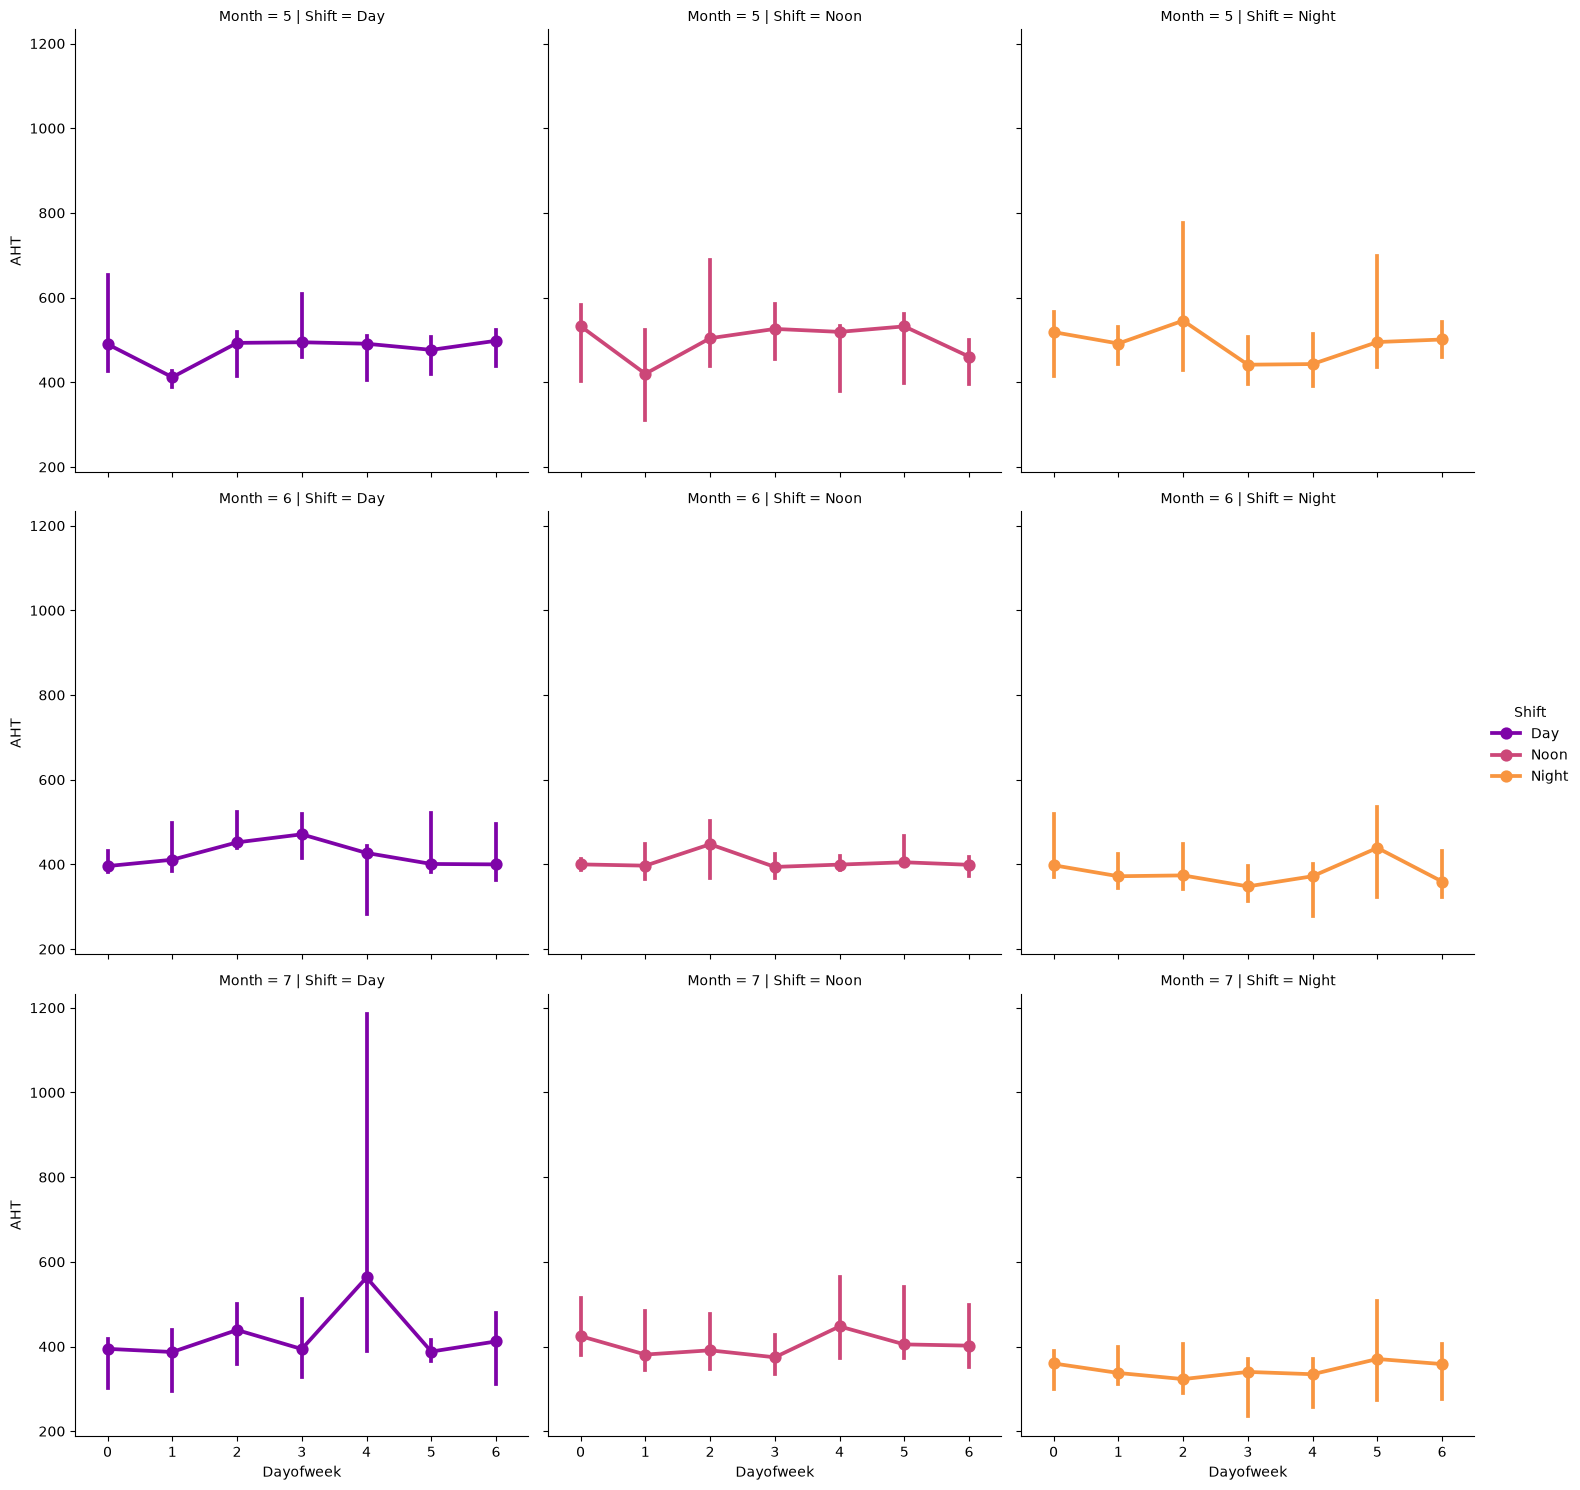

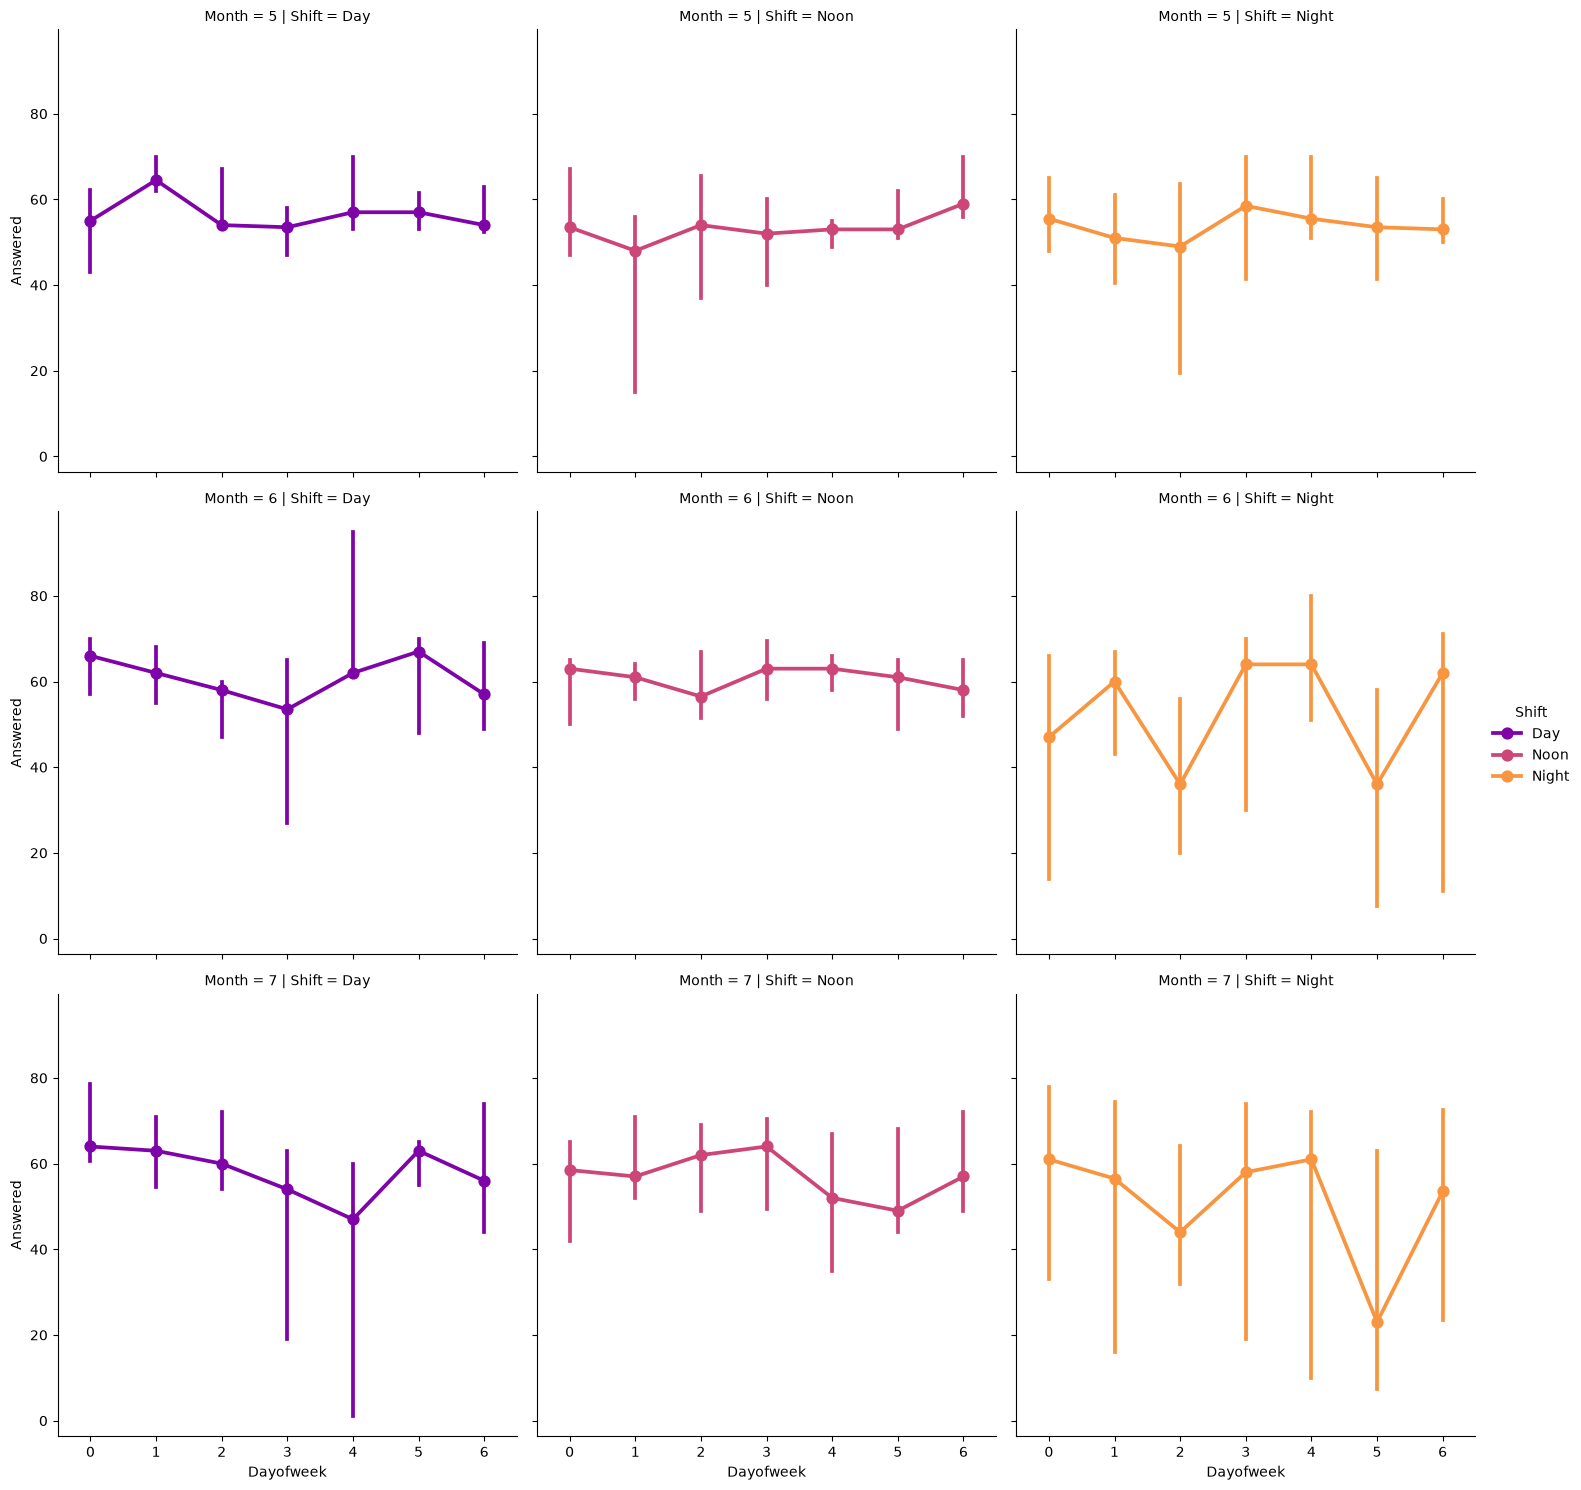

In [92]:
# 4 Shift X Temporal performance interaction

#AHT
sns.catplot(data = df, x = "Dayofweek", y = "AHT", 
               col = "Shift",
               row= "Month",
               hue="Shift",
               kind= "point",
               palette = "plasma",
               estimator=np.median,
               errorbar=("ci", 95)
)
#Answered
sns.catplot(data = df, x = "Dayofweek", y = "Answered", 
               col = "Shift",
               row= "Month",
               hue="Shift",
               kind= "point",
               palette = "plasma",
               estimator=np.median,
               errorbar=("ci", 95)
)
